<a href="https://colab.research.google.com/github/NoeliaFerrero/Comi-96160-Data-Science-II-Machine-Learning-para-la-Ciencia-de-Datos-Diplomaturas/blob/main/Semana%204%20SQL%20Avanzado%20y%20otros%20Datos/PROYECTO_INTEGRADOR_SQL_y_JSON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://notebook.google.com/notebook/b489df6f-ec17-42f5-858b-b6b7946c78f5/artifact/0a591ecb-6575-49df-84b7-9c3f214c26b5?utm_source=nlm_web_share&utm_medium=google_oo&utm_campaign=art_share_1&utm_content=&utm_smc=nlm_web_share_google_oo_art_share_1_

https://claude.ai/public/artifacts/3c654abb-8184-4fc5-a42e-1b973c2b2809

<font color='green'>***PROYECTO INTEGRADOR SQL y JSON***</font>

## 🕵️ El Caso: Manzanas Podridas

*"Las ventas suben, pero la retención cae. Sospechamos que estamos vendiendo productos 'estrella' que en realidad son de pésima calidad."*

**Antes de ver una sola línea de código:** ¿qué fuentes de datos necesitariamos para detectar esto?

El "Caso de Negocio" (Storytelling)

El Escenario: "Somos el equipo de Data de un e-commerce. El Director de Marketing nota que las ventas suben, pero la retención de clientes baja. Sospecha que estamos vendiendo productos 'estrella' que en realidad son de pésima calidad y están arruinando la marca."

El Objetivo: usar el CSV y el JSON para encontrar las "Manzanas Podridas" (productos top en ventas con reseñas desastrosas) y presentar una recomendación ejecutiva de si eliminarlos o conservarlos.

2. Puntos de Dolor Reales (Data Cleaning & Edge Cases)
En la vida real, los JSONs de APIs y los CSVs de ventas nunca vienen limpios. Agrega 2 o 3 problemas típicos que obliguen a los estudiantes a pensar:

Valores Nulos / Faltantes: Introduce productos en el CSV que no existen en el JSON de la API (ej. productos descatalogados) para que decidan si usar INNER JOIN, LEFT JOIN o FULL OUTER JOIN.

Discrepancia de Fechas / Formatos: Tipos de datos en texto en lugar de DATETIME.

Inconsistencia de IDs: ¿Qué pasa si el id_producto en el CSV está en minúsculas y en el JSON en mayúsculas? (Manejo de .str.lower()).

3. Introducción a PNL / NLP Básico (Text Mining)
Como son estudiantes de Data Science, les va a encantar dar el salto de métricas numéricas a procesamiento de lenguaje natural:

Análisis de Sentimiento Express: Usar bibliotecas simples como TextBlob o reglas léxicas básicas para clasificar los comentarios de las reseñas en Positivo, Neutro o Negativo.

Nube de Palabras (WordCloud): Filtrar los comentarios de las reseñas de 1 y 2 estrellas para generar una nube de palabras y descubrir por qué se quejan (ej. "envío", "roto", "lento", "tamaño").

## 🔗 De dos mundos separados a un solo dataset

Tenemos un CSV de ventas (transaccional, plano) y un JSON de reseñas (anidado, viene de una API).

**Predicción antes de correr:** ¿qué tipo de problema esperan encontrar al cruzar datos de dos fuentes tan distintas?

Paso 1: Cargar los archivos en Google Colab

In [ ]:
from google.colab import files
import pandas as pd
import json

# Subir los archivos si estás en Google Colab
uploaded = files.upload()

Saving reseñas_productos.json to reseñas_productos.json


In [ ]:
# Subir los archivos si estás en Google Colab
uploaded = files.upload()

Saving ventas_ecommerce.csv to ventas_ecommerce.csv


## ⚠️ Punto de decisión: ¿INNER, LEFT o FULL OUTER?

Hay productos en el CSV de ventas que **no existen** en el catálogo JSON (descatalogados).

**Antes de ver el código:** si uso INNER JOIN, ¿qué productos pierdo? ¿Y si uso LEFT?

Paso 2: Cargar y Normalizar los Datos

In [ ]:
# 1. Cargar CSV de Ventas
df_ventas = pd.read_csv('ventas_ecommerce.csv')

# 2. Cargar JSON de Reseñas de Productos
with open('reseñas_productos.json', 'r', encoding='utf-8') as f:
    datos_productos = json.load(f)

# Convertir el JSON a DataFrame (Información general del producto)
df_productos = pd.DataFrame(datos_productos)[['id_producto', 'nombre', 'categoria', 'precio', 'calificacion_promedio']]

# "Desanidar" (flatten) el array de reseñas para analizarlas individualmente por producto
df_reseñas = pd.json_normalize(
    datos_productos,
    record_path=['reseñas'],
    meta=['id_producto', 'nombre', 'categoria']
)

print("--- Muestra de Ventas ---")
display(df_ventas.head())

print("\n--- Muestra de Productos y Reseñas ---")
display(df_reseñas.head())

--- Muestra de Ventas ---


,id_venta,fecha,id_producto,id_cliente,cantidad,precio_unitario,categoria
0,VTA-10001,2026-05-01,PROD-ELE-145,CLI-1117,4,152.75,Electrónica
1,VTA-10002,2026-05-01,PROD-ELE-133,CLI-1207,1,627.64,Electrónica
2,VTA-10003,2026-05-01,PROD-ROP-118,CLI-1197,3,118.63,Ropa
3,VTA-10004,2026-05-01,PROD-ELE-149,CLI-1199,1,316.97,Electrónica
4,VTA-10005,2026-05-01,PROD-ROP-126,CLI-1024,3,53.14,Ropa



--- Muestra de Productos y Reseñas ---


,id_reseña,usuario,calificacion,fecha,comentario,util,id_producto,nombre,categoria
0,REV-001,Carlos M.,5,2026-05-10,Excelente calidad de sonido y la cancelación d...,14,PROD-ELE-101,Auriculares Inalámbricos Noise Cancelling,Electrónica
1,REV-002,Ana G.,4,2026-06-02,"Muy cómodos para usar todo el día, aunque la b...",5,PROD-ELE-101,Auriculares Inalámbricos Noise Cancelling,Electrónica
2,REV-003,Marcos P.,5,2026-07-15,Superaron mis expectativas. Los uso para traba...,8,PROD-ELE-101,Auriculares Inalámbricos Noise Cancelling,Electrónica
3,REV-004,Lucía R.,4,2026-05-18,Buen seguimiento de pulsaciones y GPS muy prec...,9,PROD-ELE-102,Smartwatch Deportivo Pro,Electrónica
4,REV-005,Diego S.,3,2026-06-20,La pantalla se ve bien al sol pero la aplicaci...,2,PROD-ELE-102,Smartwatch Deportivo Pro,Electrónica


Paso 3: Consultas Sugeridas y Análisis Cruzado
Consulta 1: Total de ingresos por categoría de producto

In [ ]:
# Agregar la columna de total_venta en el DataFrame de ventas
df_ventas['total_venta'] = df_ventas['cantidad'] * df_ventas['precio_unitario']

ventas_por_categoria = df_ventas.groupby('categoria')['total_venta'].agg(['sum', 'count', 'mean']).reset_index()
ventas_por_categoria.columns = ['Categoría', 'Ingresos Totales ($)', 'Num Ventas', 'Ticket Promedio ($)']
ventas_por_categoria = ventas_por_categoria.sort_values(by='Ingresos Totales ($)', ascending=False)

display(ventas_por_categoria)

,Categoría,Ingresos Totales ($),Num Ventas,Ticket Promedio ($)
2,Electrónica,49604.16,71,698.650141
3,Hogar y Cocina,14396.90,60,239.948333
1,Deportes,10251.45,35,292.898571
5,Ropa,10126.56,88,115.074545
0,Belleza,1728.45,27,64.016667
4,Libros,835.09,19,43.952105


Consulta 2: Top 5 Productos con mayores ingresos

In [ ]:
ventas_por_prod = df_ventas.groupby('id_producto')['total_venta'].sum().reset_index()

# Unir con el nombre del producto desde el catálogo JSON
top_productos = pd.merge(ventas_por_prod, df_productos, on='id_producto', how='inner')
top_productos = top_productos.sort_values(by='total_venta', ascending=False).head(5)

display(top_productos[['id_producto', 'nombre', 'categoria', 'total_venta', 'calificacion_promedio']])

,id_producto,nombre,categoria,total_venta,calificacion_promedio
2,PROD-ELE-104,Monitor Gamer 27 pulgadas 144Hz,Electrónica,933.32,4.5
6,PROD-ROP-101,Chaqueta Térmica de Montaña,Ropa,642.58,4.7
7,PROD-ROP-102,Zapatillas Running Cushioned,Ropa,565.49,4.3
3,PROD-HOG-101,Cafetera Express de Goteo,Hogar y Cocina,554.97,4.4
1,PROD-ELE-101,Auriculares Inalámbricos Noise Cancelling,Electrónica,265.20,4.6


Consulta 3: Cruce entre Calificación Promedio de Reseñas y Ventas Totales

In [ ]:
# Unir ventas agrupadas por producto con la información de reseñas
resumen_producto = df_ventas.groupby('id_producto').agg(
    unidades_vendidas=('cantidad', 'sum'),
    ingresos_totales=('total_venta', 'sum')
).reset_index()

cruce_completo = pd.merge(df_productos, resumen_producto, on='id_producto', how='left')
cruce_completo['unidades_vendidas'] = cruce_completo['unidades_vendidas'].fillna(0)
cruce_completo['ingresos_totales'] = cruce_completo['ingresos_totales'].fillna(0)

# Ordenar por mayor calificación y mayores ventas
display(cruce_completo.sort_values(by=['calificacion_promedio', 'ingresos_totales'], ascending=[False, False]))

,id_producto,nombre,categoria,precio,calificacion_promedio,unidades_vendidas,ingresos_totales
12,PROD-LIB-101,Libro: Hábitos Atómicos,Libros,22.00,5.0,0.0,0.00
9,PROD-HOG-103,Freidora de Aire 5L,Hogar y Cocina,115.00,4.9,1.0,102.73
2,PROD-ELE-103,Teclado Mecánico RGB,Electrónica,85.00,4.8,0.0,0.00
4,PROD-ROP-101,Chaqueta Térmica de Montaña,Ropa,95.00,4.7,9.0,642.58
13,PROD-BEL-101,Sérum Facial Ácido Hialurónico,Belleza,28.50,4.7,0.0,0.00
0,PROD-ELE-101,Auriculares Inalámbricos Noise Cancelling,Electrónica,129.99,4.6,1.0,265.20
10,PROD-DEP-101,Mat de Yoga Antideslizante 6mm,Deportes,32.00,4.6,0.0,0.00
3,PROD-ELE-104,Monitor Gamer 27 pulgadas 144Hz,Electrónica,280.00,4.5,2.0,933.32
11,PROD-DEP-102,Set de Mancuernas Ajustables 20kg,Deportes,140.00,4.5,1.0,105.34
7,PROD-HOG-101,Cafetera Express de Goteo,Hogar y Cocina,65.00,4.4,5.0,554.97


Consulta 4: Análisis de Sentimiento/Calificación de las Reseñas

In [ ]:
# Distribución de calificaciones en las reseñas escritas por los usuarios
distribucion_calificaciones = df_reseñas['calificacion'].value_counts().sort_index(ascending=False).reset_index()
distribucion_calificaciones.columns = ['Estrellas (Calificación)', 'Cantidad de Reseñas']

display(distribucion_calificaciones)

,Estrellas (Calificación),Cantidad de Reseñas
0,5,17
1,4,13
2,3,3


## Opcion B...

Código Consulta 1 (Equivalente a CTE + RANK en Pandas):

In [ ]:
import pandas as pd

# 1. Cargar archivo CSV
df_ventas = pd.read_csv('ventas_ecommerce.csv')
df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'])

# 2. Filtrar por el último mes (Julio 2026)
mes_objetivo = '2026-07'
df_mes = df_ventas[df_ventas['fecha'].dt.strftime('%Y-%m') == mes_objetivo]

# 3. CTE 1: Agrupar por categoría y producto
ventas_agrupadas = df_mes.groupby(['categoria', 'id_producto'])['cantidad'].sum().reset_index()

# 4. CTE 2: Aplicar RANK() dentro de cada categoría
ventas_agrupadas['ranking'] = ventas_agrupadas.groupby('categoria')['cantidad'].rank(method='dense', ascending=False)

# 5. Filtrar Top 3
top_3_por_categoria = ventas_agrupadas[ventas_agrupadas['ranking'] <= 3].sort_values(['categoria', 'ranking'])

display(top_3_por_categoria)

,categoria,id_producto,cantidad,ranking
5,Belleza,PROD-BEL-130,3,1.0
9,Belleza,PROD-BEL-149,3,1.0
1,Belleza,PROD-BEL-116,2,2.0
2,Belleza,PROD-BEL-118,2,2.0
6,Belleza,PROD-BEL-133,2,2.0
0,Belleza,PROD-BEL-106,1,3.0
3,Belleza,PROD-BEL-128,1,3.0
4,Belleza,PROD-BEL-129,1,3.0
7,Belleza,PROD-BEL-140,1,3.0
8,Belleza,PROD-BEL-145,1,3.0


Código Consulta 2 (Equivalente a OPENJSON en Pandas)

In [ ]:
import json

# 1. Cargar archivo JSON
with open('reseñas_productos.json', 'r', encoding='utf-8') as f:
    datos_json = json.load(f)

# 2. Desanidar (desglosar) el array interno de reseñas (OPENJSON)
df_reseñas = pd.json_normalize(
    datos_json,
    record_path=['reseñas'],
    meta=['id_producto', 'nombre', 'categoria']
)

# 3. Filtrar reseñas con nota menor a 3 (o menor/igual a 3)
reseñas_bajas = df_reseñas[df_reseñas['calificacion'] < 3]

display(reseñas_bajas[['id_producto', 'nombre', 'id_reseña', 'usuario', 'calificacion', 'comentario']])

,id_producto,nombre,id_reseña,usuario,calificacion,comentario


In [ ]:
import pandas as pd
import json

# 1. Cargar datos
df_ventas = pd.read_csv('ventas_ecommerce.csv')

with open('reseñas_productos.json', 'r', encoding='utf-8') as f:
    datos_json = json.load(f)

# 2. Extraer catálogo de productos y su promedio desde el JSON
df_productos = pd.DataFrame(datos_json)[['id_producto', 'nombre', 'categoria', 'calificacion_promedio']]

# 3. Agrupar las ventas para obtener el acumulado total por producto
df_ventas_agrup = df_ventas.groupby('id_producto').agg(
    unidades_vendidas=('cantidad', 'sum'),
    ingresos_totales=('precio_unitario', lambda p: (p * df_ventas.loc[p.index, 'cantidad']).sum())
).reset_index()

# 4. Cruce (JOIN) entre ambos datasets
df_boss = pd.merge(df_productos, df_ventas_agrup, on='id_producto', how='inner')

# 5. Filtro: Productos con promedio < 3 ordenados por los más vendidos
top5_bajo_promedio = df_boss[df_boss['calificacion_promedio'] < 3.0].sort_values(
    by='unidades_vendidas',
    ascending=False
).head(5)

# Mostrar el resultado final
display(top5_bajo_promedio)

,id_producto,nombre,categoria,calificacion_promedio,unidades_vendidas,ingresos_totales


In [ ]:
import pandas as pd
import json

# 1. Facturación total por categoría (CSV)
df_ventas = pd.read_csv('ventas_ecommerce.csv')
df_ventas['total_venta'] = df_ventas['cantidad'] * df_ventas['precio_unitario']

facturacion = df_ventas.groupby('categoria')['total_venta'].sum().reset_index()

# 2. Promedio de reseñas por categoría (JSON desanidado)
with open('reseñas_productos.json', 'r', encoding='utf-8') as f:
    datos_json = json.load(f)

df_reseñas = pd.json_normalize(datos_json, record_path=['reseñas'], meta=['categoria'])
promedio_reseñas = df_reseñas.groupby('categoria')['calificacion'].mean().reset_index()

# 3. Cruce de datos
df_bonus = pd.merge(facturacion, promedio_reseñas, on='categoria')
df_bonus.columns = ['Categoría', 'Facturación Total ($)', 'Reseña Promedio']

# Ordenar por facturación
df_bonus = df_bonus.sort_values(by='Facturación Total ($)', ascending=False)

display(df_bonus)

,Categoría,Facturación Total ($),Reseña Promedio
2,Electrónica,49604.16,4.500000
3,Hogar y Cocina,14396.90,4.428571
1,Deportes,10251.45,4.500000
5,Ropa,10126.56,4.142857
0,Belleza,1728.45,4.333333
4,Libros,835.09,5.000000


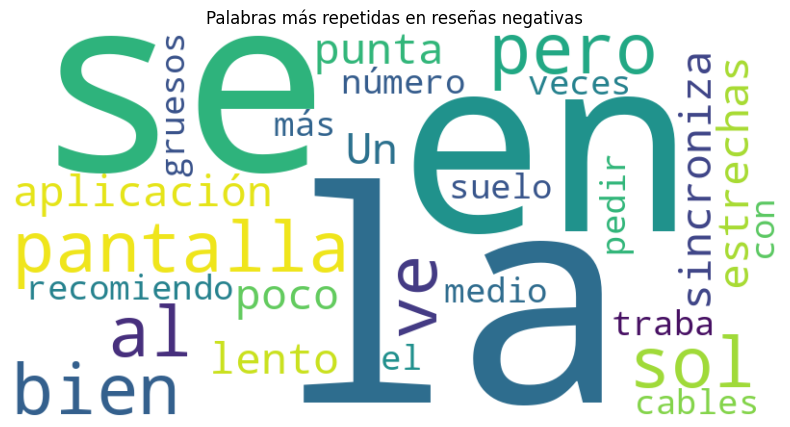

In [ ]:
# Ejemplo rápido con WordCloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

texto_quejas = " ".join(df_reseñas[df_reseñas['calificacion'] <= 3]['comentario'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(texto_quejas)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Palabras más repetidas en reseñas negativas')
plt.show()

## 🐛 Bug real: el id_producto no siempre matchea

Corran el merge tal cual está en la celda siguiente, **sin corregir nada todavía**. Cuenten cuántas filas resultan. ¿Es lo que esperaban?

## 📋 Ahora ustedes son el equipo de DS

Con lo que vieron: ¿qué producto(s) recomendarían eliminar? Argumenten con al menos un número concreto del análisis.

1. Propuestas de Mejora y Desafíos Didácticos (Data Cleaning + Edge Cases)
Para convertir esta notebook en un ejercicio desafiante y práctico, se sugiere estructurar la sección de Limpieza de Datos agregando deliberadamente los siguientes "errores del mundo real":

A. Inconsistencia de Formato en IDs (Keys Mismatch)
El Problema: En ventas_ecommerce.csv los IDs están en mayúsculas (PROD-ELE-101), mientras que en reseñas_productos.json vienen en minúsculas con espacios adicionales (prod-ele-101).

Impacto Pedagógico: Al hacer el pd.merge() inicial, el resultado dará 0 filas o perderá la mayoría de los productos.

Solución a Enseñar:

In [ ]:
df_ventas['id_producto'] = df_ventas['id_producto'].str.strip().str.upper()
df_productos['id_producto'] = df_productos['id_producto'].str.strip().str.upper()

B. Fechas como Cadenas de Texto (String Parsing)
El Problema: La columna fecha en el CSV viene en formato ambiguo (ej: "05/01/2026" vs. "2026-01-05").

Si intentan filtrar por mes usando comparaciones directas de cadenas (df['fecha'] >= '2026-07-01'), fallará o dará resultados erróneos.

In [ ]:
df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'], format='mixed')

C. Precios con Formato Monetario / Texto
El Problema: Algunas filas del CSV incluyen el símbolo de moneda ("$152.75") o comas en lugar de puntos ("152,75").

In [ ]:
df_ventas['precio_unitario'] = df_ventas['precio_unitario'].astype(str).str.replace('$', '').str.replace(',', '.').astype(float)

D. Desafío de Joins (Manejo de Nulos / Descatalogados)
El Problema: Varios productos del CSV no están en el catálogo JSON (fueron descontinuados) y viceversa (productos nuevos en el catálogo sin ventas aún).

Pregunta Guiada: ¿Qué pasa si usamos INNER vs. LEFT vs. FULL OUTER?

INNER: Pierde el historial de ventas descontinuadas.

LEFT (desde ventas): Mantiene la facturación total pero deja valores NaN en nombre/reseña.

In [ ]:
#@title AUTOCALIFICACION
import sys

from termcolor import colored, cprint

print_red_on_cyan = lambda x: cprint(x, "magenta", "on_cyan")

print('**********************************************************************************************')
print('Introduce una puntuacion para AUTOCALIFICAR tu conocimiento sobre los temas vistos\n')
print('Donde 1 es --> "POCO ❌" y 5 es --> "MUCHO ✅" \n')


def lee_entero():
   while True:
       entrada = input("En una escala del 1 al 5 ¿cuanto aprendiste sobre los temas vistos?: ")
       print('**********************************************************************************************')
       try:
           entrada = int(entrada)
           start = '⭐'
           if (entrada < 6 ):
              start = entrada * start
              print(start)
              if (entrada == 1):
                  cprint('De 10, enganchaste una...🤪')
                  cprint('pero no te preocupes, vamos a seguir repasando juntos los temas vistos en clase y tambien')
                  cprint('podemos armar unos ejercicios adicionales, que seguramente van a ser de GRAN ayuda 💪\n')
                  cprint('\t\t👉Recorda que el verdadero camino al éxito, no se trata de no fallar, \n \t\tse trata de ver ese fallo como parte integral del proceso...',"red",attrs=["bold"])
              elif (entrada == 2):
                  cprint('De 10, enganchaste algunas...lo cual es todo un logro😜')
                  cprint('\t\t👉 Recorda que todo aprendizaje depende de tu estado; busca estados \n \t\tfavorables como curiosidad, entusiasmo, satisfacción, etc. ',"magenta",attrs=["bold"])
              elif (entrada == 3):
                  cprint('¡Estamos ATR! con (r) de remo 🛶 whatttt¿??!')
                  cprint('\t\t👉Disfruta el camino, sabiendo que tus logros siempre requerirán \n \t\tde aciertos y errores',"cyan",attrs=["bold"])
              elif (entrada == 4):
                  cprint('Estamos ATR con (r) de ritmo🎼',"green",attrs=["bold"])
                  cprint('\t\t👉Felicitaciones! Vas muy bien, en definitiva el verdadero conocimiento se origina cuando seguimos \n \t\tbuscando nuevos caminos, combinamos conocimientos, iteramos...',"green",attrs=["bold"])
              elif (entrada == 5):
                  cprint('\t\t👉De 10 + IVA🍾',"green",attrs=["bold"])
                  cprint('\t\t👉Felicitaciones por todo lo aprendido hasta ahora, seguí así..!',"green",attrs=["bold"])
              return print (" \n Gracias por participar, esperamos que te lleves algo útil de este notebook 😀 ")
           else:
             cprint ("El numero ingresado no es valido: Por favor, ingresa un valor del 1 al 5","red",attrs=["bold"])
       except ValueError:
           cprint ("La entrada es incorrecta: Por favor, ingresa un caracter del 1 al 5","red",attrs=["bold"])

lee_entero()

**********************************************************************************************
Introduce una puntuacion para AUTOCALIFICAR tu conocimiento sobre los temas vistos

Donde 1 es --> "POCO ❌" y 5 es --> "MUCHO ✅" 

En una escala del 1 al 5 ¿cuanto aprendiste sobre los temas vistos?: 5
**********************************************************************************************
⭐⭐⭐⭐⭐
		👉De 10 + IVA🍾
		👉Felicitaciones por todo lo aprendido hasta ahora, seguí así..!
 
 Gracias por participar, esperamos que te lleves algo útil de este notebook 😀 


![hamsters](https://media.giphy.com/media/d1E2IByItLUuONMc/giphy.gif)